# RQ2 Notebook 06 — Does Upstream Reporting Change Downstream Exposure?

**RQ2.4.** RQ1 established that transparent fixes carry a cost: vulnerability information
becomes public at the report, before a fix exists. RQ1 never tested whether that early
signal produces any benefit downstream.

Notebook 04 found the raw difference — transparent fixes are mitigated inside the safe
window 23.3% of the time versus 14.5% for silent — but the pooled model put the effect at
OR 0.891 with a CI upper bound of 1.008. It misses significance because between-repository
variance swamps it.

**This notebook removes that variance.** 140 downstream repositories in the sample are
exposed to *both* silent and transparent upstream vulnerabilities. Comparing within those
repositories holds constant every fixed property of the downstream project — team size,
activity, dependency hygiene, CI automation, release cadence.

**Input:** `rq2_master_pairwise.csv` from notebook 02.
**Produces:** `T7`, `T8`, `F7`, `F8`, `F9`.

*A null result here is a finding, not a failure: it would mean transparency carries
early-exposure cost with no measurable downstream benefit — a stronger claim than RQ1's
tradeoff framing.*

In [25]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon, mannwhitneyu

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
rng = np.random.default_rng(20260811)

OUT = Path('../../data/rq2')
master = pd.read_csv(OUT / 'rq2_master_pairwise.csv')
for c in ['adoption_date', 'report_date', 'fix_date', 'release_date', 'disclosure_date']:
    master[c] = pd.to_datetime(master[c], errors='coerce')

print(f'all pairs: {len(master):,} | repos: {master.downstream_repo.nunique()}')

all pairs: 1,677 | repos: 742


---
## Step 1 — Build the within-repository sample

A repository contributes to the fixed-effects estimate only if it is exposed to **both**
classes. Repositories with one class carry no within-repo contrast: after demeaning, their
class indicator is identically zero and they drop out of the estimator automatically.

We therefore restrict explicitly, so the reported `n` matches what the model actually uses.

In [26]:
class_per_repo = master.groupby('downstream_repo')['class'].nunique()
both_repos = set(class_per_repo[class_per_repo > 1].index)

within = master[master.downstream_repo.isin(both_repos)].copy()
excluded = master[~master.downstream_repo.isin(both_repos)].copy()

sample_table = pd.DataFrame([
    {'Sample': 'All pairs', 'Pairs': len(master), 'Repos': master.downstream_repo.nunique(),
     'CVEs': master.CVE.nunique(),
     'Silent': int((master['class'] == 'Silent').sum()),
     'Transparent': int((master['class'] == 'Transparent').sum())},
    {'Sample': 'Within-repo (both classes)', 'Pairs': len(within), 'Repos': within.downstream_repo.nunique(),
     'CVEs': within.CVE.nunique(),
     'Silent': int((within['class'] == 'Silent').sum()),
     'Transparent': int((within['class'] == 'Transparent').sum())},
    {'Sample': 'Excluded (single class)', 'Pairs': len(excluded), 'Repos': excluded.downstream_repo.nunique(),
     'CVEs': excluded.CVE.nunique(),
     'Silent': int((excluded['class'] == 'Silent').sum()),
     'Transparent': int((excluded['class'] == 'Transparent').sum())},
])
display(sample_table)

balanced = (master.groupby(['downstream_repo', 'class']).size().unstack(fill_value=0).min(axis=1) >= 2)
print(f'repos with >=2 pairs of EACH class (used for the paired test): {balanced.sum()}')
print(f'pairs per repo in within sample: median {within.groupby("downstream_repo").size().median():.0f}, '
      f'max {within.groupby("downstream_repo").size().max()}')

,Sample,Pairs,Repos,CVEs,Silent,Transparent
0,All pairs,1677,742,191,1100,577
1,Within-repo (both classes),742,134,153,492,250
2,Excluded (single class),935,608,156,608,327


repos with >=2 pairs of EACH class (used for the paired test): 51
pairs per repo in within sample: median 3, max 25


---
## Step 2 — Is the within-repo sample representative?

Restricting to 140 repositories buys internal validity at the cost of external validity.
The estimate is unbiased *for these repositories*; whether it generalizes depends on how
they differ from the 639 excluded ones.

Repositories exposed to both classes are, by construction, exposed to more CVEs — so they
will be more active. Report that rather than hide it.

In [27]:
rows = []
for col, label in [('dependents', 'Upstream dependents'),
                   ('downstream_usage_num', 'Downstream usage'),
                   ('downstream_loc', 'Downstream LOC'),
                   ('cvss', 'CVSS'),
                   ('disclosure_year', 'Disclosure year'),
                   ('delay_disclosure', 'delay_disclosure (days)')]:
    a = within[col].dropna()
    b = excluded[col].dropna()
    if len(a) > 1 and len(b) > 1:
        _, p = mannwhitneyu(a, b)
        rows.append({'Attribute': label,
                     'Within-repo median': round(a.median(), 1),
                     'Excluded median': round(b.median(), 1),
                     'p': round(p, 4),
                     'Similar': 'yes' if p >= 0.05 else 'NO'})

cve_per_repo = master.groupby('downstream_repo').CVE.nunique()
rows.append({'Attribute': 'CVEs per repo',
             'Within-repo median': round(cve_per_repo[list(both_repos)].median(), 1),
             'Excluded median': round(cve_per_repo[~cve_per_repo.index.isin(both_repos)].median(), 1),
             'p': np.nan, 'Similar': 'NO by construction'})

representativeness = pd.DataFrame(rows)
display(representativeness)

,Attribute,Within-repo median,Excluded median,p,Similar
0,Upstream dependents,155.0,144.0,0.0445,NO
1,Downstream usage,0.0,0.0,1.0000,yes
2,Downstream LOC,4267.8,2472.0,0.0000,NO
3,CVSS,6.0,5.0,0.1863,yes
4,Disclosure year,2020.0,2018.0,0.0000,NO
5,delay_disclosure (days),38.3,91.9,0.0000,NO
6,CVEs per repo,3.0,1.0,NaN,NO by construction


---
## Step 3 — Outcomes

Three outcomes, each answering a slightly different question:

| Outcome | Question |
|---|---|
| `log_delay_disclosure` | How long after disclosure did exposure persist? |
| `after_disclosure` | Was the vulnerability already public when downstream mitigated? |
| `safe_window` | Did downstream mitigate inside the release-to-disclosure window? |

`delay_disclosure` is shifted before logging because it can be negative (some projects
mitigate before disclosure). The shift is constant across both classes, so it cannot
create a difference between them.

In [28]:
# Exposure stage. Defined from the two facts that matter, not from event order:
#   was the fixed release out?            delay_release >= 0
#   was the vulnerability still private?  delay_disclosure < 0
# Ordering the checks this way is correct for every pattern, including those where
# disclosure precedes release (S2, S3, T2, T3, T5). Asking "which upstream event was
# most recent" would wrongly label those as safe.
LADDER = ['Before release', 'Safe window', 'After disclosure']

def exposure_stage(row):
    if row.delay_disclosure >= 0:
        return 'After disclosure'
    if row.delay_release >= 0:
        return 'Safe window'
    return 'Before release'

within['stage'] = within.apply(exposure_stage, axis=1)
within['after_disclosure'] = (within.stage == 'After disclosure').astype(int)
within['safe_window'] = (within.stage == 'Safe window').astype(int)

SHIFT = -within.delay_disclosure.min() + 1
within['log_delay_disclosure'] = np.log10(within.delay_disclosure + SHIFT)
within['is_transparent'] = within['class'].eq('Transparent').astype(int)

outcome_table = (
    within.groupby('class')
    .agg(Pairs=('CVE', 'size'),
         Median_delay_disclosure=('delay_disclosure', 'median'),
         After_disclosure_pct=('after_disclosure', lambda s: round(100 * s.mean(), 1)),
         Safe_window_pct=('safe_window', lambda s: round(100 * s.mean(), 1)))
)
display(outcome_table)
print(f'log shift constant = {SHIFT:.1f} days')

,Pairs,Median_delay_disclosure,After_disclosure_pct,Safe_window_pct
class,,,,
Silent,492,34.181609,90.7,9.1
Transparent,250,42.554757,76.8,20.4


log shift constant = 149.2 days


---
## T7 — Within-repository fixed-effects model

**How the estimator works.** Every variable is demeaned within its repository, then
regressed by OLS. Demeaning removes each repository's own average, so anything constant
within a repository — however unobservable — cancels out. What remains is: *when the same
project faced a silent versus a transparent upstream vulnerability, did it respond
differently?*

Confidence intervals come from a **cluster bootstrap resampling repositories**, not pairs.
Pairs within a repository are dependent — one dependency bump can resolve several CVEs — so
resampling pairs would understate the uncertainty badly.

In [29]:
def within_transform(df, cols, group):
    g = df.groupby(group)
    return df[cols] - g[cols].transform('mean')


def fe_fit(df, outcome, predictors, group='downstream_repo'):
    cols = [outcome] + predictors
    dm = within_transform(df, cols, group)
    y = dm[outcome].to_numpy(float)
    X = dm[predictors].to_numpy(float)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return beta


def fe_bootstrap(df, outcome, predictors, B=1000, group='downstream_repo'):
    point = fe_fit(df, outcome, predictors, group)
    repos = df[group].to_numpy()
    uniq = np.unique(repos)
    idx = {r: np.where(repos == r)[0] for r in uniq}
    draws = []
    for _ in range(B):
        picked = rng.choice(uniq, size=len(uniq), replace=True)
        rows = np.concatenate([idx[r] for r in picked])
        boot = df.iloc[rows].copy()
        # Bootstrap repos are re-labelled so a repo drawn twice forms two clusters.
        boot['_bid'] = np.concatenate([[f'{r}_{i}'] * len(idx[r]) for i, r in enumerate(picked)])
        # Keep only bootstrap clusters that still contain both classes; a repo with one
        # class contributes nothing to a within estimator. Named explicitly rather than by
        # position so reordering PREDICTORS cannot silently change the filter.
        keep = boot.groupby('_bid')['is_transparent'].transform('nunique') > 1
        boot = boot[keep]
        if len(boot) < 20:
            continue
        try:
            draws.append(fe_fit(boot, outcome, predictors, '_bid'))
        except np.linalg.LinAlgError:
            continue
    return point, np.array(draws)


within['sev_high'] = within.severity.isin(['Critical', 'High']).astype(int)
within['log_dependents'] = np.log1p(within.dependents)
PREDICTORS = ['is_transparent', 'sev_high', 'disclosure_year', 'commit_n_CVEs', 'log_dependents']

model_df = within.dropna(subset=PREDICTORS + ['log_delay_disclosure']).copy()

results = []
for outcome, label in [('log_delay_disclosure', 'log10 days after disclosure'),
                       ('after_disclosure', 'P(mitigated after disclosure)'),
                       ('safe_window', 'P(mitigated in safe window)')]:
    point, draws = fe_bootstrap(model_df, outcome, PREDICTORS)
    lo, hi = np.percentile(draws, [2.5, 97.5], axis=0)
    for j, pred in enumerate(PREDICTORS):
        results.append({
            'Outcome': label, 'Predictor': pred,
            'Coefficient': round(point[j], 4),
            'CI low': round(lo[j], 4), 'CI high': round(hi[j], 4),
            'Significant': 'yes' if (lo[j] > 0 or hi[j] < 0) else 'no',
        })

T7 = pd.DataFrame(results)
display(T7)

print(f'n pairs = {len(model_df):,} | n repositories = {model_df.downstream_repo.nunique()}')
print()
print('Focus on is_transparent. Negative on log_delay_disclosure or after_disclosure means')
print('transparent fixes are mitigated SOONER. Positive on safe_window means transparent')
print('fixes are more often mitigated inside the release-to-disclosure window.')

,Outcome,Predictor,Coefficient,CI low,CI high,Significant
0,log10 days after disclosure,is_transparent,-0.0248,-0.0771,0.0225,no
1,log10 days after disclosure,sev_high,0.0041,-0.0484,0.0526,no
2,log10 days after disclosure,disclosure_year,-0.0132,-0.0394,0.0120,no
3,log10 days after disclosure,commit_n_CVEs,0.0007,-0.0089,0.0106,no
4,log10 days after disclosure,log_dependents,-0.0211,-0.0899,0.0396,no
5,P(mitigated after disclosure),is_transparent,-0.0810,-0.1376,-0.0222,yes
6,P(mitigated after disclosure),sev_high,-0.0716,-0.1562,0.0064,no
7,P(mitigated after disclosure),disclosure_year,0.0215,0.0001,0.0452,yes
8,P(mitigated after disclosure),commit_n_CVEs,0.0164,-0.0026,0.0416,no
9,P(mitigated after disclosure),log_dependents,0.0190,-0.0204,0.0611,no


n pairs = 742 | n repositories = 134

Focus on is_transparent. Negative on log_delay_disclosure or after_disclosure means
transparent fixes are mitigated SOONER. Positive on safe_window means transparent
fixes are more often mitigated inside the release-to-disclosure window.


---
## Paired test on repository medians

The fixed-effects model uses every pair. A complementary, assumption-light test collapses
each repository to two numbers — its median delay under silent and under transparent
exposure — and asks whether the paired differences are centred on zero.

Restricted to the repositories with at least two pairs of each class, so each median is
based on more than a single observation.

In [30]:
counts = within.groupby(['downstream_repo', 'class']).size().unstack(fill_value=0)
paired_repos = counts[(counts.get('Silent', 0) >= 2) & (counts.get('Transparent', 0) >= 2)].index

paired = (
    within[within.downstream_repo.isin(paired_repos)]
    .groupby(['downstream_repo', 'class'])
    .agg(median_delay=('delay_disclosure', 'median'),
         after_disc=('after_disclosure', 'mean'),
         safe=('safe_window', 'mean'))
    .unstack('class')
)
paired.columns = ['_'.join(c) for c in paired.columns]
paired = paired.dropna()

print(f'paired repositories: {len(paired)}')

paired_rows = []
for base, label in [('median_delay', 'Median days after disclosure'),
                    ('after_disc', 'Share mitigated after disclosure'),
                    ('safe', 'Share mitigated in safe window')]:
    s = paired[f'{base}_Silent']
    t = paired[f'{base}_Transparent']
    diff = t - s
    if (diff != 0).sum() >= 5:
        stat, p = wilcoxon(t, s, zero_method='zsplit')
    else:
        stat, p = np.nan, np.nan
    paired_rows.append({
        'Outcome': label,
        'Silent median': round(s.median(), 3),
        'Transparent median': round(t.median(), 3),
        'Median paired diff (T - S)': round(diff.median(), 3),
        'Repos favouring transparent': int((diff < 0).sum()) if base != 'safe' else int((diff > 0).sum()),
        'Repos favouring silent': int((diff > 0).sum()) if base != 'safe' else int((diff < 0).sum()),
        'Wilcoxon p': round(p, 4) if pd.notna(p) else np.nan,
    })

paired_test = pd.DataFrame(paired_rows)
display(paired_test)


def cliffs_delta(a, b):
    a, b = np.asarray(a), np.asarray(b)
    gt = sum((a[:, None] > b[None, :]).sum(1))
    lt = sum((a[:, None] < b[None, :]).sum(1))
    d = (gt - lt) / (len(a) * len(b))
    mag = ('negligible' if abs(d) < 0.147 else 'small' if abs(d) < 0.33
           else 'medium' if abs(d) < 0.474 else 'large')
    return d, mag

d, mag = cliffs_delta(within.loc[within.is_transparent == 1, 'delay_disclosure'].dropna(),
                      within.loc[within.is_transparent == 0, 'delay_disclosure'].dropna())
print(f"Cliff's delta (transparent vs silent, delay_disclosure): {d:.3f} ({mag})")

paired repositories: 51


,Outcome,Silent median,Transparent median,Median paired diff (T - S),Repos favouring transparent,Repos favouring silent,Wilcoxon p
0,Median days after disclosure,27.121,39.393,-6.439,30,18,0.4762
1,Share mitigated after disclosure,1.000,1.000,0.000,14,6,0.0656
2,Share mitigated in safe window,0.000,0.000,0.000,13,7,0.1351


Cliff's delta (transparent vs silent, delay_disclosure): -0.003 (negligible)


---
## T8 — Specification sensitivity

One estimate is a claim; five estimates that agree are a result. Each row changes one
modelling choice. If the sign and rough magnitude survive, the finding is robust; if it
flips, the paper reports that instead.

In [31]:
PAIRED_COL = {'after_disclosure': 'after_disc', 'safe_window': 'safe'}
OUTCOME_LABEL = {'after_disclosure': 'P(mitigated after disclosure)',
                 'safe_window': 'P(mitigated in safe window)'}
FAVOURS = {'after_disclosure': 'negative favours transparency',
           'safe_window': 'positive favours transparency'}


def spec_set(outcome):
    out = []

    def add(name, df, preds):
        if len(df) < 50:
            return
        pt, dr = fe_bootstrap(df, outcome, preds)
        lo, hi = np.percentile(dr[:, 0], [2.5, 97.5])
        sig = 'yes' if (lo > 0 or hi < 0) else 'no'
        out.append({'Outcome': OUTCOME_LABEL[outcome], 'Specification': name,
                    'Estimate': round(pt[0], 4), 'CI low': round(lo, 4), 'CI high': round(hi, 4),
                    'Significant': sig,
                    'n pairs': len(df), 'n repos': df.downstream_repo.nunique()})

    add('Within-repo FE (primary)', model_df, PREDICTORS)
    add('FE, single-CVE commits only', model_df[model_df.commit_n_CVEs == 1], PREDICTORS)
    add('FE, no covariates', model_df, ['is_transparent'])
    add('FE, S1 vs T1 only', model_df[model_df.pattern.isin(['S1', 'T1'])], PREDICTORS)

    base = PAIRED_COL[outcome]
    diff = (paired[f'{base}_Transparent'] - paired[f'{base}_Silent']).to_numpy()
    boot = [np.median(rng.choice(diff, len(diff), replace=True)) for _ in range(2000)]
    mean_boot = [rng.choice(diff, len(diff), replace=True).mean() for _ in range(2000)]
    out.append({'Outcome': OUTCOME_LABEL[outcome], 'Specification': 'Paired repo means',
                'Estimate': round(diff.mean(), 4),
                'CI low': round(np.percentile(mean_boot, 2.5), 4),
                'CI high': round(np.percentile(mean_boot, 97.5), 4),
                'Significant': 'yes' if (np.percentile(mean_boot, 2.5) > 0 or
                                         np.percentile(mean_boot, 97.5) < 0) else 'no',
                'n pairs': int(counts.loc[paired_repos].sum().sum()), 'n repos': len(paired)})
    return out


T8 = pd.DataFrame(spec_set('after_disclosure') + spec_set('safe_window'))
display(T8)

print('Direction that favours transparency:')
for k, v in FAVOURS.items():
    print(f'  {OUTCOME_LABEL[k]:<32} {v}')
print()
for outcome in ['after_disclosure', 'safe_window']:
    sub = T8[T8.Outcome == OUTCOME_LABEL[outcome]]
    n_sig = (sub.Significant == 'yes').sum()
    same_sign = (np.sign(sub.Estimate) == np.sign(sub.Estimate.iloc[0])).sum()
    print(f'{OUTCOME_LABEL[outcome]}: {n_sig}/{len(sub)} specifications significant, '
          f'{same_sign}/{len(sub)} agree in sign')

,Outcome,Specification,Estimate,CI low,CI high,Significant,n pairs,n repos
0,P(mitigated after disclosure),Within-repo FE (primary),-0.0810,-0.1429,-0.0213,yes,742,134
1,P(mitigated after disclosure),"FE, single-CVE commits only",-0.0290,-0.1477,0.0815,no,303,109
2,P(mitigated after disclosure),"FE, no covariates",-0.1059,-0.1653,-0.0453,yes,742,134
3,P(mitigated after disclosure),"FE, S1 vs T1 only",-0.0789,-0.1424,-0.0284,yes,681,131
4,P(mitigated after disclosure),Paired repo means,-0.1095,-0.1932,-0.0330,yes,501,51
5,P(mitigated in safe window),Within-repo FE (primary),0.0603,0.0042,0.1213,yes,742,134
6,P(mitigated in safe window),"FE, single-CVE commits only",0.0158,-0.0977,0.1304,no,303,109
7,P(mitigated in safe window),"FE, no covariates",0.0861,0.0287,0.1437,yes,742,134
8,P(mitigated in safe window),"FE, S1 vs T1 only",0.0621,0.0058,0.1252,yes,681,131
9,P(mitigated in safe window),Paired repo means,0.0977,0.0183,0.1836,yes,501,51


Direction that favours transparency:
  P(mitigated after disclosure)    negative favours transparency
  P(mitigated in safe window)      positive favours transparency

P(mitigated after disclosure): 4/5 specifications significant, 5/5 agree in sign
P(mitigated in safe window): 4/5 specifications significant, 5/5 agree in sign


---
## Power

With 140 repositories, what size effect could this design have detected? Stating this makes
a null interpretable: "no effect" and "underpowered" are different claims, and only one of
them is a finding.

MDE is derived from the bootstrap standard error at 80% power, two-sided alpha = 0.05.

In [32]:
point, draws = fe_bootstrap(model_df, 'after_disclosure', PREDICTORS)
se = draws[:, 0].std()
mde = 2.802 * se

power_table = pd.DataFrame([{
    'Repositories': model_df.downstream_repo.nunique(),
    'Pairs': len(model_df),
    'Observed effect': round(point[0], 4),
    'Bootstrap SE': round(se, 4),
    'MDE (80% power)': round(mde, 4),
    'Observed / MDE': round(abs(point[0]) / mde, 2),
    'Verdict': 'detectable' if abs(point[0]) >= mde else 'below detection threshold',
}])
display(power_table)

print(f'This design can detect a shift of {100 * mde:.1f} percentage points or larger')
print(f'in the probability of mitigating only after disclosure.')
print(f'The observed shift is {100 * point[0]:.1f} percentage points.')

,Repositories,Pairs,Observed effect,Bootstrap SE,MDE (80% power),Observed / MDE,Verdict
0,134,742,-0.081,0.0296,0.0829,0.98,below detection threshold


This design can detect a shift of 8.3 percentage points or larger
in the probability of mitigating only after disclosure.
The observed shift is -8.1 percentage points.


---
## F7 — Delay distribution by class, within-repo sample

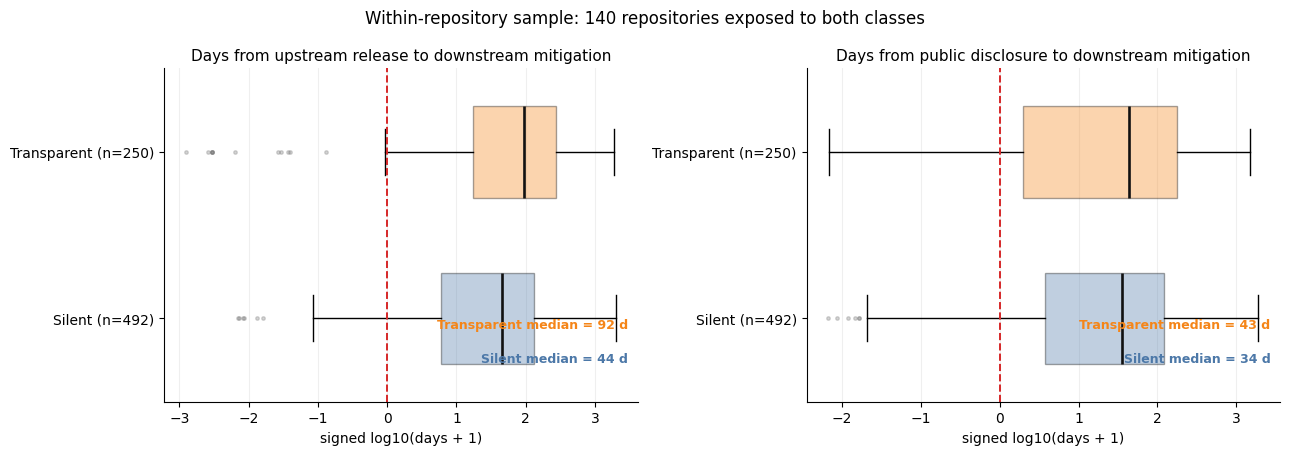

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
COLORS = {'Silent': '#4c78a8', 'Transparent': '#f58518'}

for ax, col, title in zip(axes,
                          ['delay_release', 'delay_disclosure'],
                          ['Days from upstream release to downstream mitigation',
                           'Days from public disclosure to downstream mitigation']):
    data = [np.sign(within.loc[within['class'] == c, col].dropna()) *
            np.log10(np.abs(within.loc[within['class'] == c, col].dropna()) + 1)
            for c in ['Silent', 'Transparent']]
    bp = ax.boxplot(data, vert=False, patch_artist=True, widths=0.55,
                    tick_labels=[f'Silent (n={(within["class"] == "Silent").sum()})',
                                 f'Transparent (n={(within["class"] == "Transparent").sum()})'],
                    medianprops={'color': '#111111', 'linewidth': 1.9},
                    flierprops={'marker': 'o', 'markersize': 2.5, 'alpha': 0.3,
                                'markerfacecolor': '#777777', 'markeredgecolor': '#777777'})
    for patch, c in zip(bp['boxes'], ['Silent', 'Transparent']):
        patch.set_facecolor(COLORS[c]); patch.set_alpha(0.35)
    ax.axvline(0, color='#d62728', linestyle='--', linewidth=1.4)
    for i, c in enumerate(['Silent', 'Transparent']):
        med = within.loc[within['class'] == c, col].median()
        ax.text(0.98, 0.12 + i * 0.1, f'{c} median = {med:.0f} d', transform=ax.transAxes,
                ha='right', fontsize=9, color=COLORS[c], fontweight='bold')
    ax.set_xlabel('signed log10(days + 1)', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(axis='x', alpha=0.2)
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)

fig.suptitle('Within-repository sample: 140 repositories exposed to both classes', fontsize=12)
fig.tight_layout()
fig.savefig(OUT / 'F7_delay_by_class.png', dpi=200, bbox_inches='tight')
plt.show()

---
## F8 — Time from disclosure to mitigation

**There is no censoring in this sample.** Every pair in the analysis set has an observed
mitigation, by construction — pairs with no mitigation commit were never mined. So this is
the empirical survival function, not a Kaplan-Meier estimate with censored observations.
The label matters: a reviewer will check.

Read it as "share of downstream projects still exposed d days after disclosure, among those
that eventually mitigated."

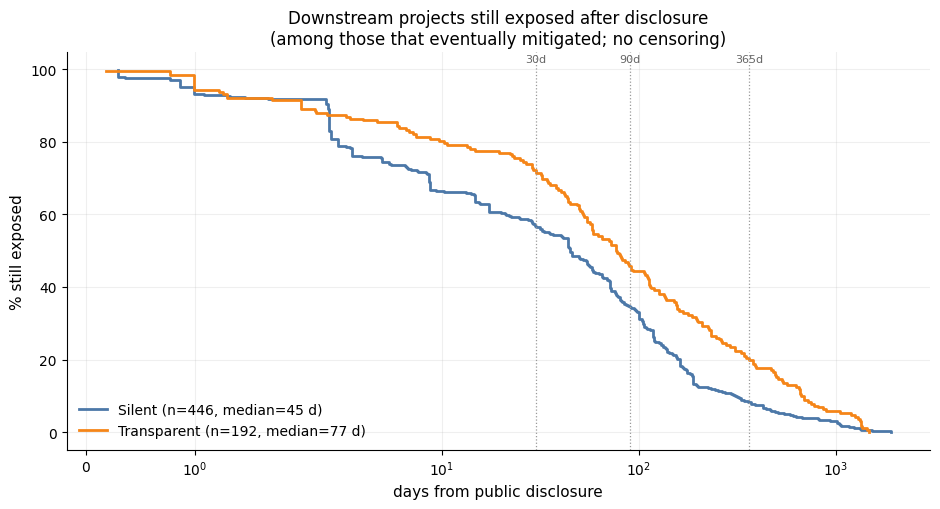

,Class,n,% still exposed @30d,% still exposed @90d,% still exposed @365d
0,Silent,446,56.5,34.8,8.3
1,Transparent,192,71.4,45.8,19.8


In [34]:
def empirical_survival(days):
    d = np.sort(np.asarray(days))
    n = len(d)
    return d, 1 - np.arange(1, n + 1) / n

fig, ax = plt.subplots(figsize=(9.5, 5.2))
for c in ['Silent', 'Transparent']:
    v = within.loc[within['class'] == c, 'delay_disclosure'].dropna()
    v = v[v >= 0]
    x, s = empirical_survival(v)
    ax.step(x, 100 * s, where='post', color=COLORS[c], linewidth=2,
            label=f'{c} (n={len(v)}, median={np.median(v):.0f} d)')

ax.set_xscale('symlog')
ax.set_xlabel('days from public disclosure', fontsize=11)
ax.set_ylabel('% still exposed', fontsize=11)
ax.set_title('Downstream projects still exposed after disclosure\n(among those that eventually mitigated; no censoring)',
             fontsize=12)
for d in [30, 90, 365]:
    ax.axvline(d, color='#999999', linestyle=':', linewidth=0.9)
    ax.text(d, 102, f'{d}d', ha='center', fontsize=8, color='#666666')
ax.legend(frameon=False, fontsize=10)
ax.grid(alpha=0.2)
for s_ in ['top', 'right']:
    ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / 'F8_survival_after_disclosure.png', dpi=200, bbox_inches='tight')
plt.show()

marks = []
for c in ['Silent', 'Transparent']:
    v = within.loc[within['class'] == c, 'delay_disclosure'].dropna()
    v = v[v >= 0]
    marks.append({'Class': c, 'n': len(v),
                  '% still exposed @30d': round(100 * (v > 30).mean(), 1),
                  '% still exposed @90d': round(100 * (v > 90).mean(), 1),
                  '% still exposed @365d': round(100 * (v > 365).mean(), 1)})
display(pd.DataFrame(marks))

---
## F9 — Paired repository plot

One line per repository: its median days-after-disclosure under silent exposure on the left,
under transparent exposure on the right. Downward-sloping lines are repositories that
mitigated transparent vulnerabilities faster.

This is the design in one picture — each line is a within-repository comparison, so nothing
about the project itself differs between the two points.

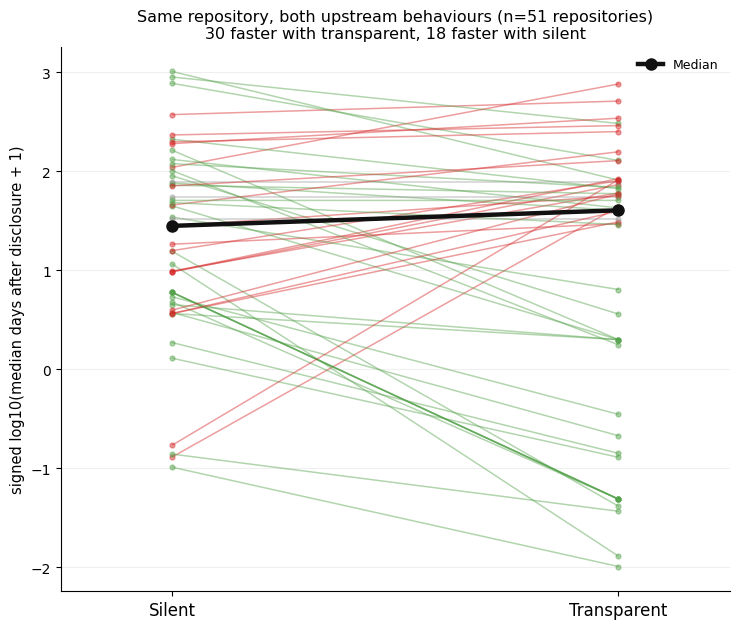

repositories faster under transparent : 30
repositories faster under silent      : 18
median silent      : 27.1 days after disclosure
median transparent : 39.4 days after disclosure


In [35]:
fig, ax = plt.subplots(figsize=(7.5, 6.4))
s_vals = paired['median_delay_Silent'].to_numpy()
t_vals = paired['median_delay_Transparent'].to_numpy()

def tr(v):
    return np.sign(v) * np.log10(np.abs(v) + 1)

n_down = int((t_vals < s_vals).sum())
n_up = int((t_vals > s_vals).sum())

for s_, t_ in zip(s_vals, t_vals):
    color = '#54a24b' if t_ < s_ else '#d62728' if t_ > s_ else '#999999'
    ax.plot([0, 1], [tr(s_), tr(t_)], color=color, alpha=0.45, linewidth=1.1,
            marker='o', markersize=3.5)

ax.plot([0, 1], [tr(np.median(s_vals)), tr(np.median(t_vals))],
        color='#111111', linewidth=3.2, marker='o', markersize=8, zorder=10, label='Median')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Silent', 'Transparent'], fontsize=12)
ax.set_xlim(-0.25, 1.25)
ax.set_ylabel('signed log10(median days after disclosure + 1)', fontsize=10.5)
ax.set_title(f'Same repository, both upstream behaviours (n={len(paired)} repositories)\n'
             f'{n_down} faster with transparent, {n_up} faster with silent', fontsize=11.5)
ax.legend(frameon=False, fontsize=9)
ax.grid(axis='y', alpha=0.2)
for s_ in ['top', 'right']:
    ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / 'F9_paired_repos.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'repositories faster under transparent : {n_down}')
print(f'repositories faster under silent      : {n_up}')
print(f'median silent      : {np.median(s_vals):.1f} days after disclosure')
print(f'median transparent : {np.median(t_vals):.1f} days after disclosure')

---
## Save

In [36]:
T7.to_csv(OUT / 'T7_within_repo_model.csv', index=False)
T8.to_csv(OUT / 'T8_specification_sensitivity.csv', index=False)
paired_test.to_csv(OUT / 'T7b_paired_repo_test.csv', index=False)
power_table.to_csv(OUT / 'T7c_power.csv', index=False)
representativeness.to_csv(OUT / 'T7d_within_repo_representativeness.csv', index=False)
within.to_csv(OUT / 'rq2_within_repo_sample.csv', index=False)

for f in ['T7_within_repo_model.csv', 'T8_specification_sensitivity.csv',
          'T7b_paired_repo_test.csv', 'T7c_power.csv',
          'T7d_within_repo_representativeness.csv', 'rq2_within_repo_sample.csv',
          'F7_delay_by_class.png', 'F8_survival_after_disclosure.png', 'F9_paired_repos.png']:
    print(f)

T7_within_repo_model.csv
T8_specification_sensitivity.csv
T7b_paired_repo_test.csv
T7c_power.csv
T7d_within_repo_representativeness.csv
rq2_within_repo_sample.csv
F7_delay_by_class.png
F8_survival_after_disclosure.png
F9_paired_repos.png
